<a href="https://colab.research.google.com/github/mpconsultsai/msc-project-csc-40098/blob/main/training/notebooks/training_text_distilbert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab — DistilBERT text baseline (MSC RQ1)

Fine-tunes DistilBERT on the frozen `fake_news_final_text.tsv` cohort. Same splits as the TF-IDF baseline (`cohort_text.py`): Fakeddit official + FNN 80/20 stratified, seed **42**. Full cohort ~44,090 train rows (~30–90 min on a T4). Outputs → `runs/text_distilbert_baseline/` and `My Drive/runs/`. Setup steps are in the cell below.

## How to run this notebook (Google Colab)

**What it does:** trains and evaluates the **DistilBERT text baseline**. Needs a **GPU runtime** (a free T4 is sufficient).

**Before you run:**
1. **Add the shared project folder to your Google Drive** (one-time) so these paths exist — the setup cell reads them:
   - `My Drive/training/src/` — helper modules (`colab_setup.py`, `cohort_*.py`)
   - `My Drive/data/fake_news_final_text.tsv` — the frozen text cohort (~17 MB)

   If the folder was *shared with you*, open it in Drive and click **“Add shortcut to Drive”** so it appears under `My Drive/`.
2. **Set the runtime:** `Runtime → Change runtime type → T4 GPU`.
3. **(Recommended)** `File → Save a copy in Drive` so your edits and outputs persist.

**Then `Runtime → Run all`** (or run the cells top to bottom in order):
- **Bootstrap** — mounts Drive and copies `training/` into the session.
- **Dependencies** — `install_dependencies(["text"])` installs the pinned libraries.
- **Setup** — `require_cuda()` checks the GPU and copies the TSV in.
- The remaining cells train and evaluate, saving to `runs/text_distilbert_baseline/` (and persisting it to `My Drive/runs/`).

> **Troubleshooting**
> - `No module named 'google'` → you’re not on a hosted Colab runtime. Open this in the Colab browser tab and connect to a **hosted** runtime (not “local”).
> - `No module named 'colab_setup'` → the **Bootstrap** cell hasn’t run successfully yet, or `My Drive/training/src/` is missing. Run Bootstrap first and confirm the Drive layout above.
> - GPU error from `require_cuda()` → set the runtime to **T4 GPU** (step 2), then `Runtime → Restart and run all`.

In [1]:
# Bootstrap — mount Drive and copy training/ (identical cell in all Colab notebooks)
import shutil
import sys
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/msc")
TRAINING_SRC = Path("/content/drive/MyDrive/training")
TRAINING = PROJECT_ROOT / "training"
if not TRAINING_SRC.is_dir():
    raise FileNotFoundError(
        "Sync repo training/ to My Drive/training/ (modules under training/src/)"
    )
if TRAINING.exists():
    shutil.rmtree(TRAINING)
shutil.copytree(TRAINING_SRC, TRAINING)
sys.path.insert(0, str(TRAINING / "src"))
print("PROJECT_ROOT:", PROJECT_ROOT, "| training:", TRAINING)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/msc | training: /content/msc/training


In [2]:
from colab_setup import install_dependencies

# Pinned, version-synced installs (single source of truth: colab_setup.PINNED_DEPENDENCIES).
install_dependencies(["text"])

Installing pinned dependencies: scikit-learn==1.5.2 pandas==2.2.2 transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2
Resolved dependency versions:
    scikit-learn: 1.5.2
          pandas: 2.2.2
    transformers: 4.44.2
        datasets: 2.21.0
      accelerate: 0.34.2
           torch: 2.11.0+cu128
     torchvision: 0.26.0+cu128


{'scikit-learn': '1.5.2',
 'pandas': '2.2.2',
 'transformers': '4.44.2',
 'datasets': '2.21.0',
 'accelerate': '0.34.2',
 'torch': '2.11.0+cu128',
 'torchvision': '0.26.0+cu128'}

## Setup

The cell below checks the GPU (`require_cuda()`) and copies the text TSV into the runtime.

In [3]:
from colab_setup import require_cuda, setup_colab_project

require_cuda()
ctx = setup_colab_project(
    tsv_names=["fake_news_final_text.tsv"],
    need_images=False,
)
PROJECT_ROOT = ctx.project_root
TSV_PATH = ctx.tsv_paths["fake_news_final_text.tsv"]
print("TSV_PATH:", TSV_PATH)

CUDA: True | GPU: Tesla T4
VRAM GB: 15.6
TSV: /content/msc/data/fake_news_final_text.tsv
Training helpers: /content/msc/training
Setup OK: ColabSetup(project_root=PosixPath('/content/msc'), data_dir=PosixPath('/content/msc/data'), training_dir=PosixPath('/content/msc/training'), images_dir=PosixPath('/content/msc/data/processed/images'), image_count=0, tsv_paths={'fake_news_final_text.tsv': PosixPath('/content/msc/data/fake_news_final_text.tsv')})
TSV_PATH: /content/msc/data/fake_news_final_text.tsv


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

EXPECTED_ROWS = 48_878
RANDOM_SEED = 42
FNN_TRAIN_FRAC = 0.8

df = pd.read_csv(TSV_PATH, sep="\t", dtype=str, keep_default_na=False)
assert len(df) == EXPECTED_ROWS
assert df["label_binary"].isin(["0", "1"]).all()
df["label_binary"] = df["label_binary"].astype("int64")

df["split_study"] = ""
fd = df["dataset"] == "fakeddit"
df.loc[fd, "split_study"] = df.loc[fd, "split_official"]
fnn = df["dataset"] == "fakenewsnet"
tr_idx, va_idx = train_test_split(
    df.index[fnn],
    train_size=FNN_TRAIN_FRAC,
    random_state=RANDOM_SEED,
    stratify=df.loc[fnn, "label_binary"],
)
df.loc[tr_idx, "split_study"] = "train"
df.loc[va_idx, "split_study"] = "validation"

train_df = df[df["split_study"] == "train"].copy()
val_df = df[df["split_study"] == "validation"].copy()
print("train:", len(train_df), "| val:", len(val_df))

train: 44090 | val: 4788


## Model and training settings

**Run order:** execute **Data (Google Drive)** and **split** cells above first. The training cell below will reload splits automatically if the runtime was restarted.

**Checkpoint:** [`distilbert/distilbert-base-uncased`](https://huggingface.co/distilbert/distilbert-base-uncased) on Hugging Face (Sanh et al., 2019; distilled from BERT-base).

The [model card](https://huggingface.co/distilbert/distilbert-base-uncased) is useful mainly for **what this checkpoint is**, not task-specific hyperparameters:

| From the model card | Relevance to this notebook |
|---------------------|----------------------------|
| **Sequence classification** is an intended downstream use | Matches `AutoModelForSequenceClassification` + fine-tuning on fake/real labels |
| **Uncased** tokenisation (lowercase English) | Appropriate for noisy social-media post text |
| **Smaller/faster than BERT-base** (~67M parameters) | Practical full-cohort fine-tune on Colab T4 within MSc scope |
| Pretrained on BookCorpus + Wikipedia | General English representations; task signal comes from our labels |
| **Limitations / bias** | Fine-tuned models can inherit pretrained bias — note in thesis ethics if discussing fairness |

We load the checkpoint with Hugging Face `transformers` (`AutoTokenizer`, `AutoModelForSequenceClassification`), as shown on the model card.

**Expected log message (not an error):** when loading, you may see that `classifier` / `pre_classifier` weights were *newly initialized*. That is normal — the public checkpoint is pretrained for language modelling; we attach a fresh 2-class head and learn it during fine-tuning (`trainer.train()` below).

**Fixed hyperparameters (no validation-set tuning; same split policy as TF–IDF):**

| Setting | Value | Rationale |
|---------|-------|-----------|
| `MAX_LENGTH` | 128 | Short social text; avoids padding very long sequences |
| `EPOCHS` | 2 | Standard short fine-tune budget for BERT-family models |
| `LR` | `2e-5` | Conventional fine-tuning rate for DistilBERT |
| `BATCH_SIZE` | 32 | T4 GPU on Colab (`require_cuda()` in setup) |
| Class weights | Balanced | Addresses real/fake imbalance without threshold tuning |

**Outputs:** metrics and model save to `runs/text_distilbert_baseline/` and `My Drive/runs/`.


In [5]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

RANDOM_SEED = 42
EXPECTED_ROWS = 48_878
FNN_TRAIN_FRAC = 0.8


def load_train_val_frames():
    """Reload cohort splits if an earlier cell was skipped or the runtime restarted."""
    if "TSV_PATH" not in globals() or not Path(TSV_PATH).is_file():
        raise RuntimeError(
            "TSV_PATH is not set. Run the Google Drive / data cell above first."
        )
    df = pd.read_csv(TSV_PATH, sep="\t", dtype=str, keep_default_na=False)
    assert len(df) == EXPECTED_ROWS
    assert df["label_binary"].isin(["0", "1"]).all()
    df["label_binary"] = df["label_binary"].astype("int64")

    df["split_study"] = ""
    fd = df["dataset"] == "fakeddit"
    df.loc[fd, "split_study"] = df.loc[fd, "split_official"]
    fnn = df["dataset"] == "fakenewsnet"
    tr_idx, va_idx = train_test_split(
        df.index[fnn],
        train_size=FNN_TRAIN_FRAC,
        random_state=RANDOM_SEED,
        stratify=df.loc[fnn, "label_binary"],
    )
    df.loc[tr_idx, "split_study"] = "train"
    df.loc[va_idx, "split_study"] = "validation"

    train = df[df["split_study"] == "train"].copy()
    val = df[df["split_study"] == "validation"].copy()
    return train, val


if "train_df" not in globals() or "val_df" not in globals():
    train_df, val_df = load_train_val_frames()
    print("Reloaded splits | train:", len(train_df), "| val:", len(val_df))

# --- toggles ---
DISTILBERT_MODEL = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 32  # Colab T4; require_cuda() in setup cell
EPOCHS = 2
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL, num_labels=2
)

cw = torch.tensor(
    compute_class_weight(
        "balanced", classes=np.array([0, 1]), y=train_df["label_binary"]
    ),
    dtype=torch.float32,
)


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        w = self.class_weights.to(outputs.logits.device)
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=w)
        return (loss, outputs) if return_outputs else loss


def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


train_ds = Dataset.from_pandas(
    train_df[["text", "label_binary"]].set_axis(["text", "labels"], axis=1),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label_binary"]].set_axis(["text", "labels"], axis=1),
    preserve_index=False,
)
print(f"FULL train rows: {len(train_ds)}")

train_ds = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
val_ds = val_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

args = TrainingArguments(
    output_dir="/content/distilbert_out",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    learning_rate=LR,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none",
    seed=RANDOM_SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,  # transformers 4.44.x (pinned); use processing_class on newer HF
    class_weights=cw,
)

t0 = time.perf_counter()
trainer.train()
print(f"Train time: {(time.perf_counter() - t0) / 60:.1f} min")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model chec

FULL train rows: 44090


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,0.422200,0.406406
2,0.334400,0.404634


Train time: 12.2 min


## Validation metrics and curves

Threshold-free curves use **`score_fake`** (softmax probability for class 1). Default **0.5** threshold gives accuracy / macro-F1 / the classification report below.

Validation metrics (pooled val, threshold=0.5):
  accuracy:  0.8285
  macro_f1:  0.8275
  roc_auc:   0.9040
  avg_prec:  0.9140  (area under PR curve)

              precision    recall  f1-score   support

    real (0)       0.80      0.83      0.81      2176
    fake (1)       0.85      0.83      0.84      2612

    accuracy                           0.83      4788
   macro avg       0.83      0.83      0.83      4788
weighted avg       0.83      0.83      0.83      4788



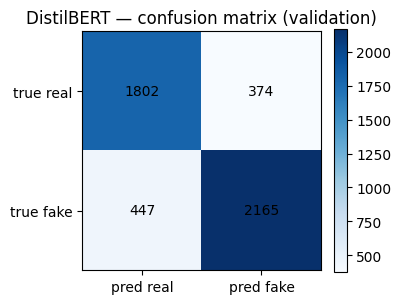

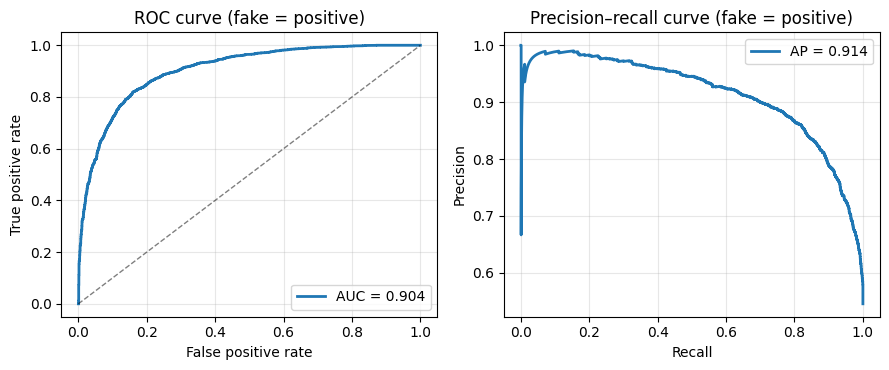

,sample_id,dataset,y_true,y_pred,score_fake
42954,fd:151xr9,fakeddit,1,1,0.872824
42955,fd:ba8djo,fakeddit,1,1,0.914406
42956,fd:9cjhoa,fakeddit,0,0,0.003831
42957,fd:9am49y,fakeddit,0,0,0.051889
42958,fd:d7hb1v,fakeddit,1,1,0.986711


In [6]:
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

pred = trainer.predict(val_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_score = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
y_val = val_df["label_binary"].to_numpy()

acc = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average="macro")
roc_auc = roc_auc_score(y_val, y_score)
avg_precision = average_precision_score(y_val, y_score)

print("Validation metrics (pooled val, threshold=0.5):")
print(f"  accuracy:  {acc:.4f}")
print(f"  macro_f1:  {macro_f1:.4f}")
print(f"  roc_auc:   {roc_auc:.4f}")
print(f"  avg_prec:  {avg_precision:.4f}  (area under PR curve)")
print()
print(classification_report(y_val, y_pred, target_names=["real (0)", "fake (1)"]))

# --- confusion matrix ---
cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fig_cm, ax_cm = plt.subplots(figsize=(4, 3.5))
im = ax_cm.imshow(cm, cmap="Blues")
ax_cm.set_xticks([0, 1], labels=["pred real", "pred fake"])
ax_cm.set_yticks([0, 1], labels=["true real", "true fake"])
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
ax_cm.set_title("DistilBERT — confusion matrix (validation)")
fig_cm.colorbar(im, ax=ax_cm, fraction=0.046)
plt.tight_layout()
plt.show()

# --- ROC + precision-recall ---
fpr, tpr, _ = roc_curve(y_val, y_score)
prec, rec, _ = precision_recall_curve(y_val, y_score)

fig_curves, axes = plt.subplots(1, 2, figsize=(9, 3.8))

axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (fake = positive)")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, lw=2, label=f"AP = {avg_precision:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall curve (fake = positive)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

pred_df = val_df[["sample_id", "dataset"]].copy()
pred_df["y_true"] = y_val
pred_df["y_pred"] = y_pred
pred_df["score_fake"] = y_score
display(pred_df.head())

In [7]:
import json
from google.colab import files

RUN_DIR = PROJECT_ROOT / "runs" / "text_distilbert_baseline"
RUN_DIR.mkdir(parents=True, exist_ok=True)

metrics = {
    "model": DISTILBERT_MODEL,
    "train_rows": len(train_ds),
    "val_rows": len(val_df),
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "roc_auc": float(roc_auc),
    "average_precision": float(avg_precision),
    "epochs": EPOCHS,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "split_policy": "fakeddit_official_plus_fnn_80_20_seed_42",
    "random_seed": RANDOM_SEED,
}

metrics_path = RUN_DIR / "metrics.json"
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

pred_df.to_csv(RUN_DIR / "predictions_val.tsv", sep="\t", index=False)
for fig, name in ((fig_cm, "confusion_matrix.png"), (fig_curves, "roc_pr_curves.png")):
    fig.savefig(RUN_DIR / name, dpi=150, bbox_inches="tight")

trainer.save_model(RUN_DIR / "model")
tokenizer.save_pretrained(RUN_DIR / "model")

from colab_setup import persist_run_to_drive

persist_run_to_drive(RUN_DIR)

print(json.dumps(metrics, indent=2))
print("Saved:", RUN_DIR)
print("Checkpoints persisted to My Drive/runs/ — fusion notebook will sync automatically.")

files.download(str(metrics_path))

Persisted to Drive: /content/drive/MyDrive/runs/text_distilbert_baseline
{
  "model": "distilbert-base-uncased",
  "train_rows": 44090,
  "val_rows": 4788,
  "accuracy": 0.8285296574770259,
  "macro_f1": 0.8275383749740877,
  "roc_auc": 0.9039763098482119,
  "average_precision": 0.9140053065617151,
  "epochs": 2,
  "max_length": 128,
  "batch_size": 32,
  "learning_rate": 2e-05,
  "split_policy": "fakeddit_official_plus_fnn_80_20_seed_42",
  "random_seed": 42
}
Saved: /content/msc/runs/text_distilbert_baseline
Checkpoints persisted to My Drive/runs/ — fusion notebook will sync automatically.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>